# #1. Retail Dataset For Meaningful Insights

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#1. then we bring the dataset

retail_sales_dataset = pd.read_csv('retail_sales_dataset.csv')

In [ ]:
retail_sales_dataset

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [ ]:
# Cleaning the dataset

retail_sales_dataset.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [ ]:
# check redundant rows

retail_sales_dataset.duplicated().sum()

np.int64(0)

# #2.Then We move to Descriptive Statistics Calculate basic statistics (mean, median, mode, standard deviation).

In [ ]:
#2. Then We move to Descriptive Statistics Calculate basic statistics (mean, median, mode, standard deviation).

print("Columns in the dataset:")
retail_sales_dataset_columns = retail_sales_dataset.columns
print(retail_sales_dataset_columns)

print("\nDescriptive statistics for each column:")

for column in retail_sales_dataset_columns:

    print(f"\n--- Statistics for column: {column} ---")
    if pd.api.types.is_numeric_dtype(retail_sales_dataset[column]):
        print(f"Count: {retail_sales_dataset[column].count()}")
        print(f"Mean: {retail_sales_dataset[column].mean():.2f}")
        print(f"Median: {retail_sales_dataset[column].median():.2f}")
        print(f"Standard Deviation: {retail_sales_dataset[column].std():.2f}")

    else:
        # non - numeric
        print(retail_sales_dataset[column].describe())
        print("Mode:")
        # .mode() returns a Series, take the first element if not empty
        print(retail_sales_dataset[column].mode().iloc[0] if not retail_sales_dataset[column].mode().empty else "No mode found")

Columns in the dataset:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

Descriptive statistics for each column:

--- Statistics for column: Transaction ID ---
Count: 1000
Mean: 500.50
Median: 500.50
Standard Deviation: 288.82

--- Statistics for column: Date ---
count           1000
unique           345
top       2023-05-16
freq              11
Name: Date, dtype: object
Mode:
2023-05-16

--- Statistics for column: Customer ID ---
count         1000
unique        1000
top       CUST1000
freq             1
Name: Customer ID, dtype: object
Mode:
CUST001

--- Statistics for column: Gender ---
count       1000
unique         2
top       Female
freq         510
Name: Gender, dtype: object
Mode:
Female

--- Statistics for column: Age ---
Count: 1000
Mean: 41.39
Median: 42.00
Standard Deviation: 13.68

--- Statistics for column: Product Category ---
count         1000
unique       

# #3. Time Series Analysis: Analyze sales trends over time using time series techniques.

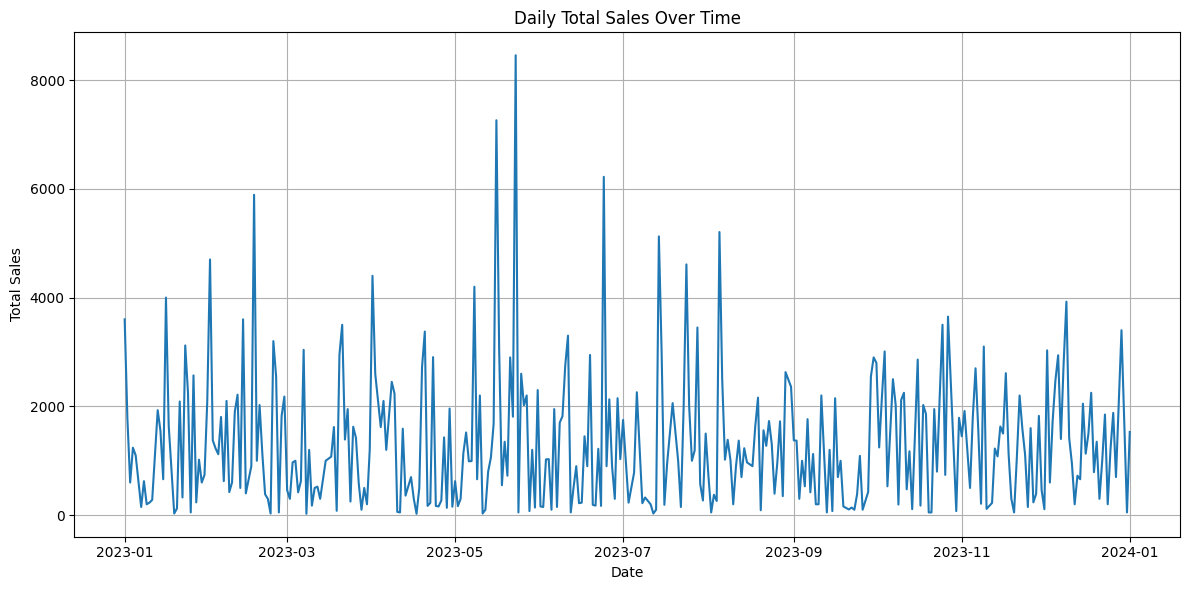

In [ ]:
#3. Time Series Analysis: Analyze sales trends over time using time series techniques.

# Ensure 'Date' column is datetime type
retail_sales_dataset['Date'] = pd.to_datetime(retail_sales_dataset['Date'])

# Sort the dataset by Date for time series analysis
retail_sales_dataset_sorted = retail_sales_dataset.sort_values(by='Date')

# Aggregate total sales per day
daily_sales = retail_sales_dataset_sorted.groupby('Date')['Total Amount'].sum().reset_index()

# Create the line chart using seaborn
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Total Amount', data=daily_sales)
plt.title('Daily Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

# #4. Customer and Product Analysis: Analyze customer demographics and purchasing behavior.

In [ ]:
#4. Customer and Product Analysis: Analyze customer demographics and purchasing behavior.

# first analyze using which gender by doing much transactions ( GROUP BY ) and also total quantity

retail_sales_dataset_gender = retail_sales_dataset.groupby('Gender').agg(
    total_amount=('Total Amount', 'sum'),
    total_quantity=('Quantity', 'sum')
).reset_index()

retail_sales_dataset_gender

,Gender,total_amount,total_quantity
0,Female,232840,1298
1,Male,223160,1216


Here We Can Say That **Female** has much Transactions amount

In [ ]:
# now we find according to age category ( Young , Adult , Middle-aged , Seniors )

# Define age bins and labels based on the user's request
# Ages below 18 will not be categorized, as the ranges start from 18.
bins = [17, 25, 35, 50, retail_sales_dataset['Age'].max() + 1]
labels = ['Young Adults', 'Adults', 'Middle-aged', 'Seniors']

# Create 'Age Category' column. `right=True` means (start, end]
# This categorizes ages as follows:
# (17, 25] -> 18-25 (Young Adults)
# (25, 35] -> 26-35 (Adults)
# (35, 50] -> 36-50 (Middle-aged)
# (50, max_age] -> 51+ (Seniors)
retail_sales_dataset['Age Category'] = pd.cut(
    retail_sales_dataset['Age'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=False
)

# Group by 'Age Category' and calculate total amount and total quantity
retail_sales_dataset_age_category = retail_sales_dataset.groupby('Age Category').agg(
    total_amount=('Total Amount', 'sum'),
    total_quantity=('Quantity', 'sum')
).reset_index()

# Create a dictionary to map Age Category to its range string
age_range_map = {
    'Young Adults': '18->25',
    'Adults': '26->35',
    'Middle-aged': '36->50',
    'Seniors': f'51->{int(retail_sales_dataset['Age'].max())}'
}
retail_sales_dataset_age_category['Age_range'] = retail_sales_dataset_age_category['Age Category'].map(age_range_map)

# Reorder columns to place 'Age_range' after 'Age Category'
retail_sales_dataset_age_category = retail_sales_dataset_age_category[['Age Category', 'Age_range', 'total_amount', 'total_quantity']]

display(retail_sales_dataset_age_category)

/tmp/ipykernel_38738/2307174283.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  retail_sales_dataset_age_category = retail_sales_dataset.groupby('Age Category').agg(


,Age Category,Age_range,total_amount,total_quantity
0,Young Adults,18->25,84550,412
1,Adults,26->35,98480,540
2,Middle-aged,36->50,139660,785
3,Seniors,51->64,133310,777


In [ ]:
# now analyze customer behaviour ( which product category buys most & no of products that bought )


retail_sales_dataset_product_category = retail_sales_dataset.groupby('Product Category').agg(
    total_amount=('Total Amount', 'sum'),
    total_quantity=('Quantity', 'sum')
).reset_index()

retail_sales_dataset_product_category

,Product Category,total_amount,total_quantity
0,Beauty,143515,771
1,Clothing,155580,894
2,Electronics,156905,849


# #5. Visualization: Present insights through bar charts, line plots, and heatmaps.

/tmp/ipykernel_38738/2660429424.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product Category', y='total_quantity', data=retail_sales_dataset_product_category, palette='viridis')


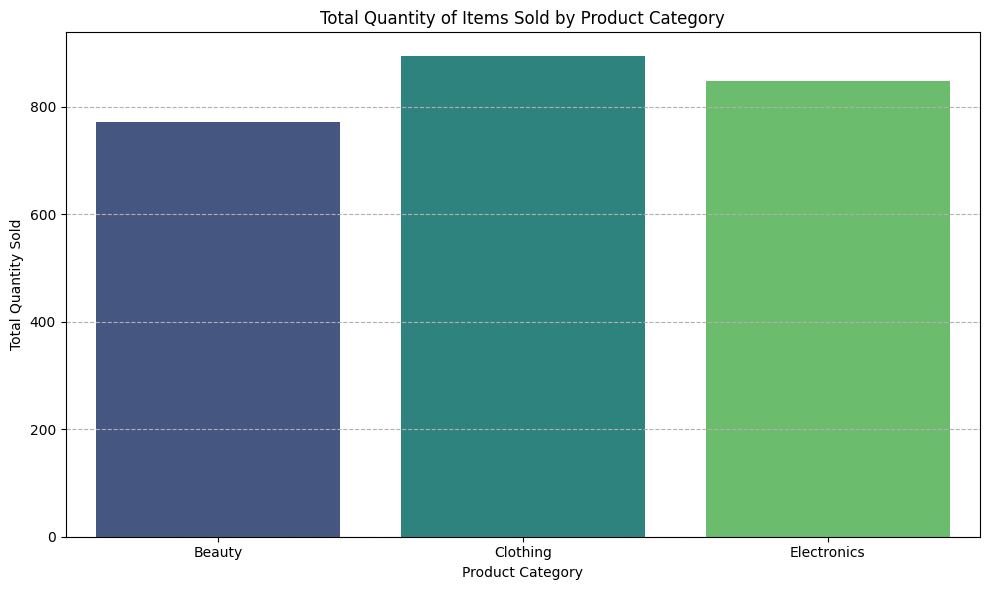

In [ ]:
#5. Visualization: Present insights through bar charts, line plots, and heatmaps.

# first using bar charts of each product cateogry which bought most

plt.figure(figsize=(10, 6))
sns.barplot(x='Product Category', y='total_quantity', data=retail_sales_dataset_product_category, palette='viridis')
plt.title('Total Quantity of Items Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

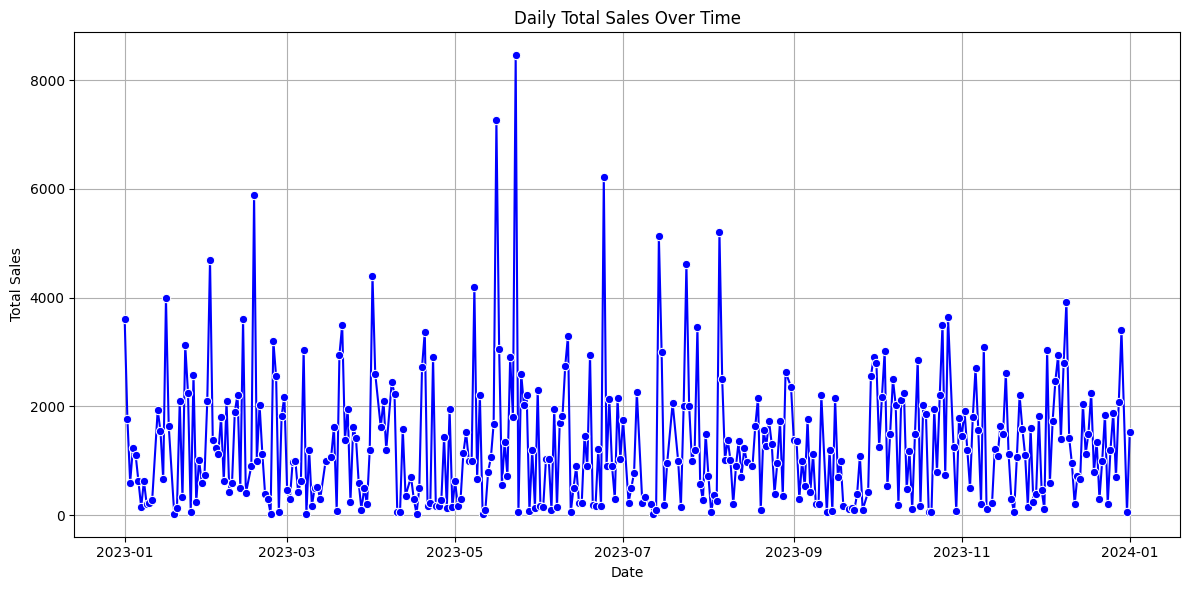

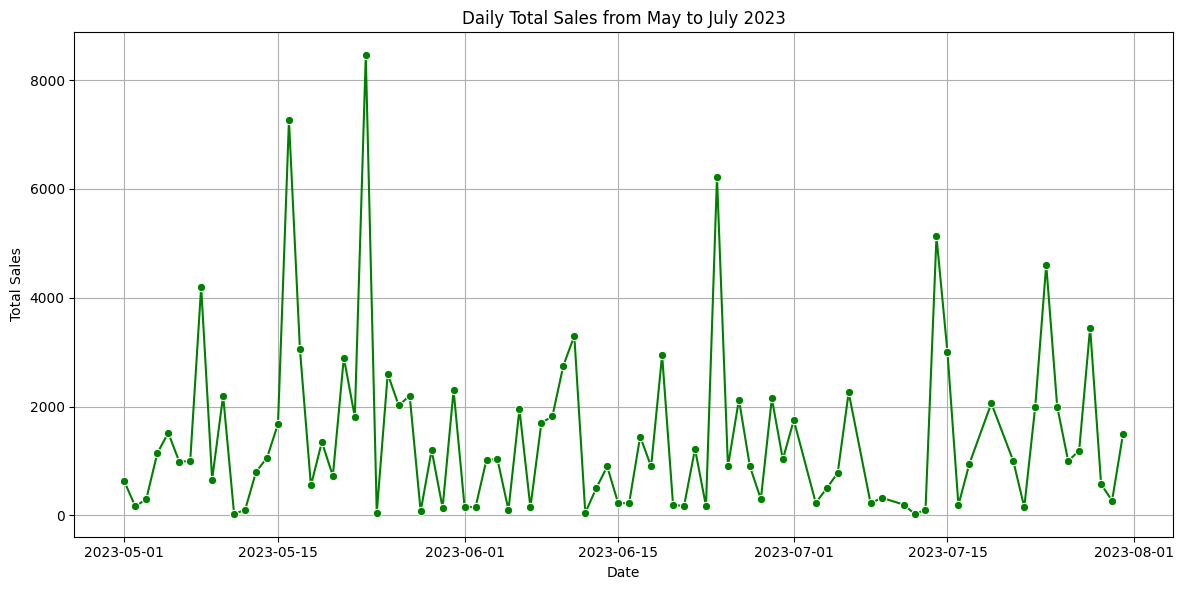

In [ ]:
# line charts analysis

plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Total Amount', data=daily_sales, marker='o', color='blue')
plt.title('Daily Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.tight_layout()
plt.show()


# for particular month between the 2023-05 to 2023-07

# Filter daily_sales for the specified date range
monthly_sales_2023_05_to_07 = daily_sales[
    (daily_sales['Date'] >= '2023-05-01') & (daily_sales['Date'] <= '2023-07-31')
]

plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Total Amount', data=monthly_sales_2023_05_to_07, marker='o', color='green')
plt.title('Daily Total Sales from May to July 2023')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

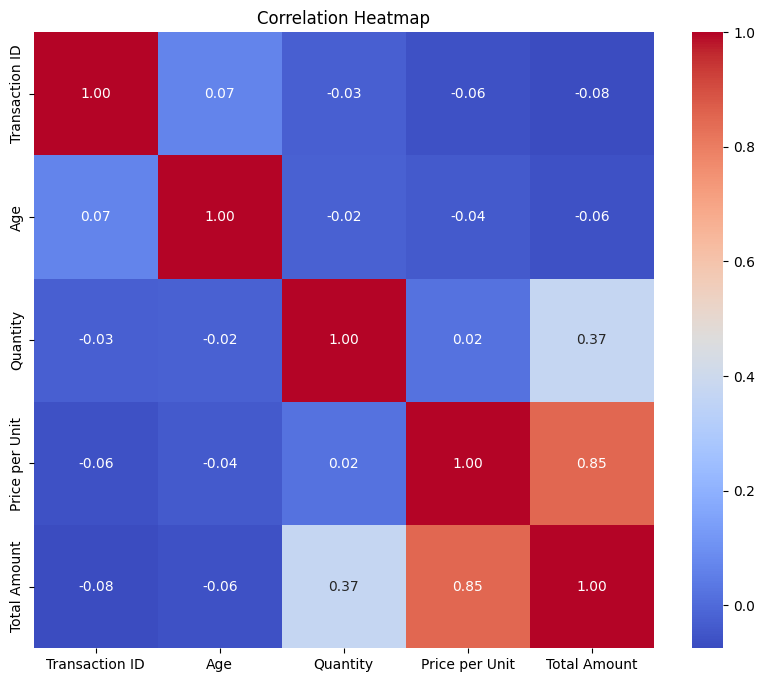

In [ ]:
# heatmap ( between the attributes correlations )

# Select only numeric columns for correlation calculation
numeric_retail_sales_dataset = retail_sales_dataset.select_dtypes(include=['number'])

correlation_matrix = numeric_retail_sales_dataset.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# #6. Recommendations

## Specific Recommendations Based on EDA Results:

Based on the current EDA, here are tailored recommendations to further enhance your understanding and potentially drive business decisions:

### 1. Deeper Dive into Price and Total Amount Distribution:
*   **Observation**: The descriptive statistics showed that `Price per Unit` and `Total Amount` have a mean significantly higher than their median (e.g., `Price per Unit` Mean: 179.89, Median: 50.00; `Total Amount` Mean: 456.00, Median: 135.00), indicating a highly skewed distribution with a few high-value transactions.
*   **Recommendation**: Investigate these high-value transactions more closely. What product categories, customer demographics, or dates are associated with them? Are there specific premium products or bulk purchases driving these numbers? Consider creating price segments (e.g., 'Economy', 'Mid-range', 'Premium') for `Price per Unit` and analyze sales performance across these segments.

### 2. Granular Time Series Analysis:
*   **Observation**: The daily sales line plot provides a good overview, but with 345 unique dates over a year, there's potential for more detailed temporal insights.
*   **Recommendation**:
    *   **Decompose Time Series**: Apply time series decomposition (e.g., seasonal-trend decomposition) to isolate trend, seasonality, and residuals from the daily sales data. This can reveal underlying patterns that aren't immediately obvious from a simple line plot.
    *   **Weekly/Monthly Aggregations**: Aggregate sales data to weekly and monthly levels to smooth out daily fluctuations and identify broader seasonal or periodic sales cycles.
    *   **Day of Week/Month Analysis**: Extract `day_of_week`, `day_of_month`, and `month` features from the `Date` column and analyze average sales for each. For instance, do sales peak on weekends or specific days of the week? This was suggested in the general recommendations, but the daily sales data makes it particularly relevant here.

### 3. Customer Segmentation Refinement:
*   **Observation**: The analysis showed `Middle-aged` and `Seniors` as the top age categories by total amount and quantity, and `Female` customers having slightly higher transactions.
*   **Recommendation**:
    *   **Cross-segmentation**: Combine `Gender` and `Age Category` to see if there are specific high-value customer segments (e.g., 'Middle-aged Females').
    *   **Product Preferences by Segment**: Analyze which `Product Category` each `Age Category` or `Gender` segment prefers. This can inform targeted marketing campaigns and inventory strategies.
    *   **Customer Lifetime Value (CLV)**: While not directly available, considering the `Total Amount` and `Quantity` per customer could be a proxy to start understanding customer value. Introduce RFM (Recency, Frequency, Monetary) analysis if individual customer purchase history over time is available for a deeper CLV study.

### 4. Product Category Deep Dive:
*   **Observation**: `Electronics` and `Clothing` generate the highest total amounts, while `Clothing` has the highest quantity sold.
*   **Recommendation**:
    *   **Profitability Analysis**: If profit margins per product or category are available, analyze these to understand which categories are most profitable, not just highest in revenue/quantity.
    *   **Inventory Management**: Given `Clothing` has high quantity, investigate its stock turnover rate. For `Beauty`, which has lower overall sales, assess if it's a strategic category (e.g., high margin, draws specific customers).
    *   **Price Elasticity**: Consider analyzing if changes in `Price per Unit` for specific `Product Categories` affect `Quantity` or `Total Amount` significantly.

### 5. Advanced Correlation Insights:
*   **Observation**: The heatmap confirmed strong expected correlations between `Quantity`, `Price per Unit`, and `Total Amount`.
*   **Recommendation**: Beyond direct correlations, consider exploring relationships between categorical variables (e.g., using Chi-square tests for independence) or applying techniques like Principal Component Analysis (PCA) if more numerical features were present, to reduce dimensionality and uncover latent patterns among variables.